# **PYSM3** 

[PySM 3](https://pysm3.readthedocs.io/en/latest/#) generates full-sky simulations of Galactic foregrounds in intensity and polarization relevant for CMB experiments. The components simulated are: thermal dust, synchrotron, AME, free-free, and CMB at a given HEALPix 𝑁𝑠⁢𝑖⁢𝑑⁢𝑒, with an option to integrate over a bandpass and to smooth with a given beam.

There is scope for a few options for the model for each component, attempting to be consistent with current data.

Currently much of the available data is limited in resolution at degree-scale. We therefore make efforts to provide reasonable small-scale simulations to extend the data to higher multipoles. The details of the procedures developed can be found in the accompanying paper.

This code is based on the large-scale Galactic part of [Planck Sky Model](https://apc.u-paris.fr/~delabrou/PSM/psm.html) ([Delabrouille 2012](https://arxiv.org/abs/1207.3675)) code and uses some of its inputs.

***



In [1]:
import pysm3
import pysm3.units as u
import numpy as np
import healpy as hp


## Models

Each model is identified with a letter and a number, the letter indicates the kind of emission and the number the type of model, generally in order of complexity starting at 1.

### Dust

- **d1**: Thermal dust is modelled as a single-component modified black body (mbb). We use dust templates for emission at 545 GHz in intensity and 353 GHz in polarisation from the Planck-2015 analysis, and scale these to different frequencies with a mbb spectrum using the spatially varying temperature and spectral index obtained from the Planck data using the Commander code (Planck Collaboration 2015, arXiv:1502.01588).
- **d10**: 
- **d11**: like d10 with stochastic small scales generated on-the-fly. It can reproduce d10 if configured to run with a specific set of seeds and a specific $\ell_{max}$, see [ModifiedBlackBodyRealization](https://pysm3.readthedocs.io/en/latest/api/pysm3.ModifiedBlackBodyRealization.html#pysm3.ModifiedBlackBodyRealization). However reproducing d10 is expensive because it needs to generate small scales with a $\ell_{max} =16384$ whatever output resolution is required, normally instead d11 generates small scales just up to $\ell_{max} =2.5⁢N_{side}$.

### Synchrotron

- **s1**: A power law scaling is used for the synchrotron emission, with a spatially varying spectral index. The emission templates are the Haslam 408 MHz, 57’ resolution data reprocessed by Remazeilles et al 2015 MNRAS 451, 4311, and the WMAP 9-year 23 GHz Q/U maps (Bennett, C.L., et.al., 2013, ApJS, 208, 20B). 
- **s5**:
- **s6**: like s5 with stochastic small scales generated on-the-fly. It can reproduce s5 if configured to run with a specific set of seeds and a specific $\ell_{max}$, see [PowerLawRealization](https://pysm3.readthedocs.io/en/latest/api/pysm3.PowerLawRealization.html#pysm3.PowerLawRealization). However reproducing s5 is expensive because it needs to generate small scales with a $\ell_{max} =16384$ whatever output resolution is required, normally instead s6 generates small scales just up to $\ell_{max} =3⁢N_{side} −1$.

### Cosmic Infrared Background (CIB)

- **cib1**: Cosmic Infrared Background map built from the WebSky 0.4 simulation, it is generated at several input frequencies and then linearly interpolated in uK_RJ by PySM. Available at $N_{side} =4096$. It also includes an analytical correction to its amplitude to match the South Pole Telescope data. For more details see [WebSky](https://pysm3.readthedocs.io/en/latest/websky.html#websky).

***

Let's see how create maps with these models and their differences:

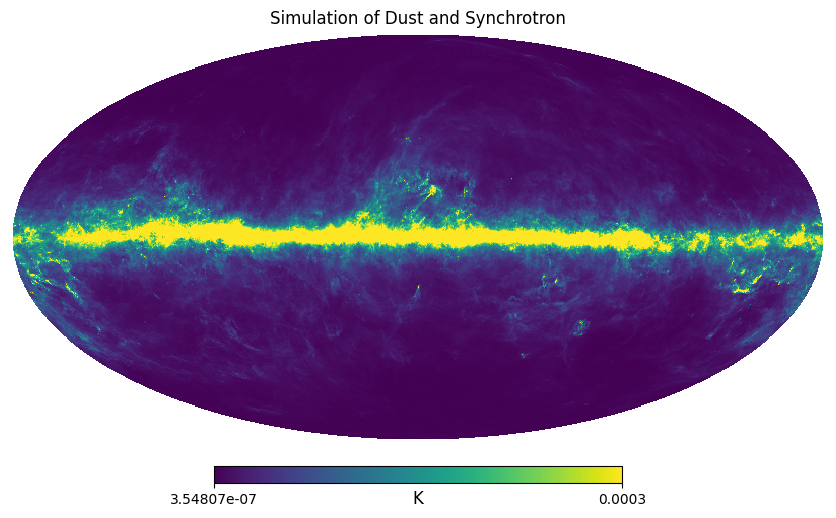

In [2]:
# Here you make a sky with your models
sky1 = pysm3.Sky(nside=2048, preset_strings=["d1"], output_unit="K_CMB")
# Here you get de emission in frequencies 
map_1 = sky1.get_emission(
    freq=100 * u.GHz
)

# map_1[0] = I ,map_1[1] = Q and map_1[2] = U 

hp.mollview(map_1[0],title="Simulation of Dust and Synchrotron", max=3e-4,  unit="K")

Let's see now models more complex than s1 and d1.

Let's practice with models as S11 and d6, because in small scales they are stochastic.

/home/jorge/miniconda3/envs/cosmo310/lib/python3.10/site-packages/healpy/fitsfunc.py:676: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/jorge/miniconda3/envs/cosmo310/lib/python3.10/site-packages/healpy/fitsfunc.py:677: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
No physical unit associated with file /home/jorge/.astropy/cache/download/url/5eef745c2c721c70901c600cc4f1ba27/contents
/home/jorge/miniconda3/envs/cosmo310/lib/python3.10/site-packages/healpy/sphtfunc.py:621: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/jorge/miniconda3/envs/cosmo310/lib/python3.10/site-packages/healpy/sphtfunc.py:577: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


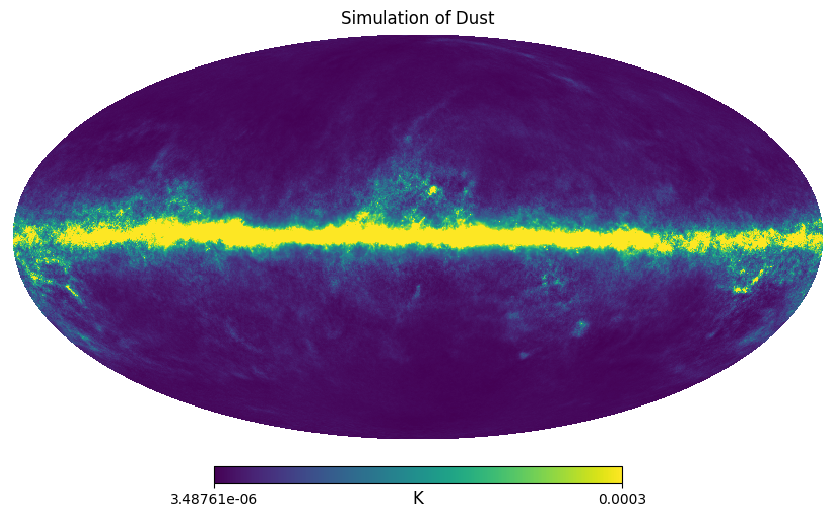

In [3]:
# Here you make a sky with your models

sky2 = pysm3.Sky(nside=2048, preset_strings=["d11"], output_unit="K_CMB")
# Here you get de emission in frequencies 
map_2 = sky2.get_emission(
    freq=100 * u.GHz
)

# map_1[0] = I ,map_1[1] = Q and map_1[2] = U 

hp.mollview(map_2[0],title="Simulation of Dust", max=3e-4,  unit="K")

For example, we can see the diference between s1 and s11 models.

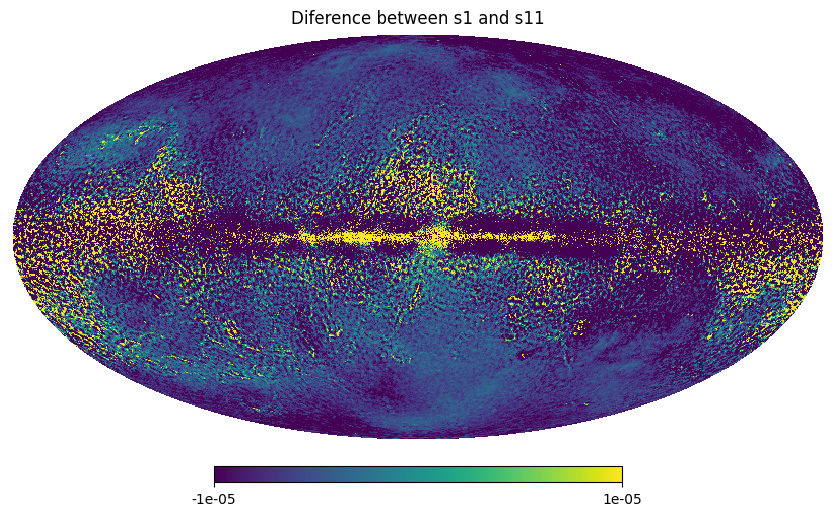

In [4]:
map_rest = map_1[0] - map_2[0]

hp.mollview(map_rest,title="Diference between s1 and s11", min = -1e-5, max=1e-5)

Now for delensing, we will use these models (s11, d6) since stochastic changes introduce statistical uncertainty and affect the estimators.

But if we want a more realistic scenario, we should adjust the parameters of the foreground. This will be more complex, because it requires a systematic analysis and parameters distributions.
